# CA Groundwater: Restored vs. NWIS

Maps unique restored groundwater locations (clipped to CA) against
NWIS CA groundwater monitoring sites with `begin_year <= 1979`.

Output: `manuscript/figures/ca_groundwater_nwis_map.png`

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

root         = Path('../..')
parquet_path = root / 'data/analysis/processed_metadata.parquet'
spatial_path = root / 'data/analysis/spatial'
nwis_path    = root / 'data/analysis/nwis_sites'
figures_path = root / 'manuscript/figures'
figures_path.mkdir(parents=True, exist_ok=True)

NWIS_COLOR     = '#4477AA'
RESTORED_COLOR = '#EE6677'

df = pd.read_parquet(parquet_path)
print(f'Loaded {len(df):,} metadata rows')

Loaded 109,440 metadata rows


In [2]:
# CA state shapefile
ca = gpd.read_file(spatial_path / 'ca_shapefile/ca_poly.shp').to_crs('EPSG:4326')
xmin, ymin, xmax, ymax = ca.total_bounds
buf = 0.3
CA_XMIN, CA_XMAX = xmin - buf, xmax + buf
CA_YMIN, CA_YMAX = ymin - buf, ymax + buf
print(f'CA bounds: lon [{xmin:.2f}, {xmax:.2f}]  lat [{ymin:.2f}, {ymax:.2f}]')

CA bounds: lon [-124.39, -114.13]  lat [32.54, 42.00]


In [3]:
# Restored groundwater — unique lat/lon locations, clipped to CA boundary
gw = df[
    (df['water_type_clean'] == 'Groundwater') &
    df['lat_combined'].notna() &
    df['lon_combined'].notna()
].drop_duplicates(subset=['lat_combined', 'lon_combined'])

gdf_all = gpd.GeoDataFrame(
    gw,
    geometry=gpd.points_from_xy(gw['lon_combined'], gw['lat_combined']),
    crs='EPSG:4326'
)
gdf_restored = gpd.sjoin(gdf_all, ca[['geometry']], how='inner', predicate='within')
print(f'Restored groundwater unique locations (within CA): {len(gdf_restored):,}')

Restored groundwater unique locations (within CA): 5,981


In [4]:
# NWIS CA groundwater sites — begin_year <= 1979
nwis = pd.read_csv(nwis_path / 'ca_groundwater_sites.csv', low_memory=False)
nwis_hist = nwis[
    (nwis['begin_year'] <= 1979) &
    nwis['dec_lat_va'].notna() &
    nwis['dec_long_va'].notna()
].drop_duplicates(subset=['site_no'])

gdf_nwis = gpd.GeoDataFrame(
    nwis_hist,
    geometry=gpd.points_from_xy(nwis_hist['dec_long_va'], nwis_hist['dec_lat_va']),
    crs='EPSG:4326'
)
print(f'NWIS groundwater sites (begin_year <= 1979): {len(gdf_nwis):,}')
print(f'  begin_year range: {nwis_hist["begin_year"].min()} - {nwis_hist["begin_year"].max()}')

NWIS groundwater sites (begin_year <= 1979): 32,618
  begin_year range: 1890 - 1979


Saved: ..\..\manuscript\figures\ca_groundwater_nwis_map.png


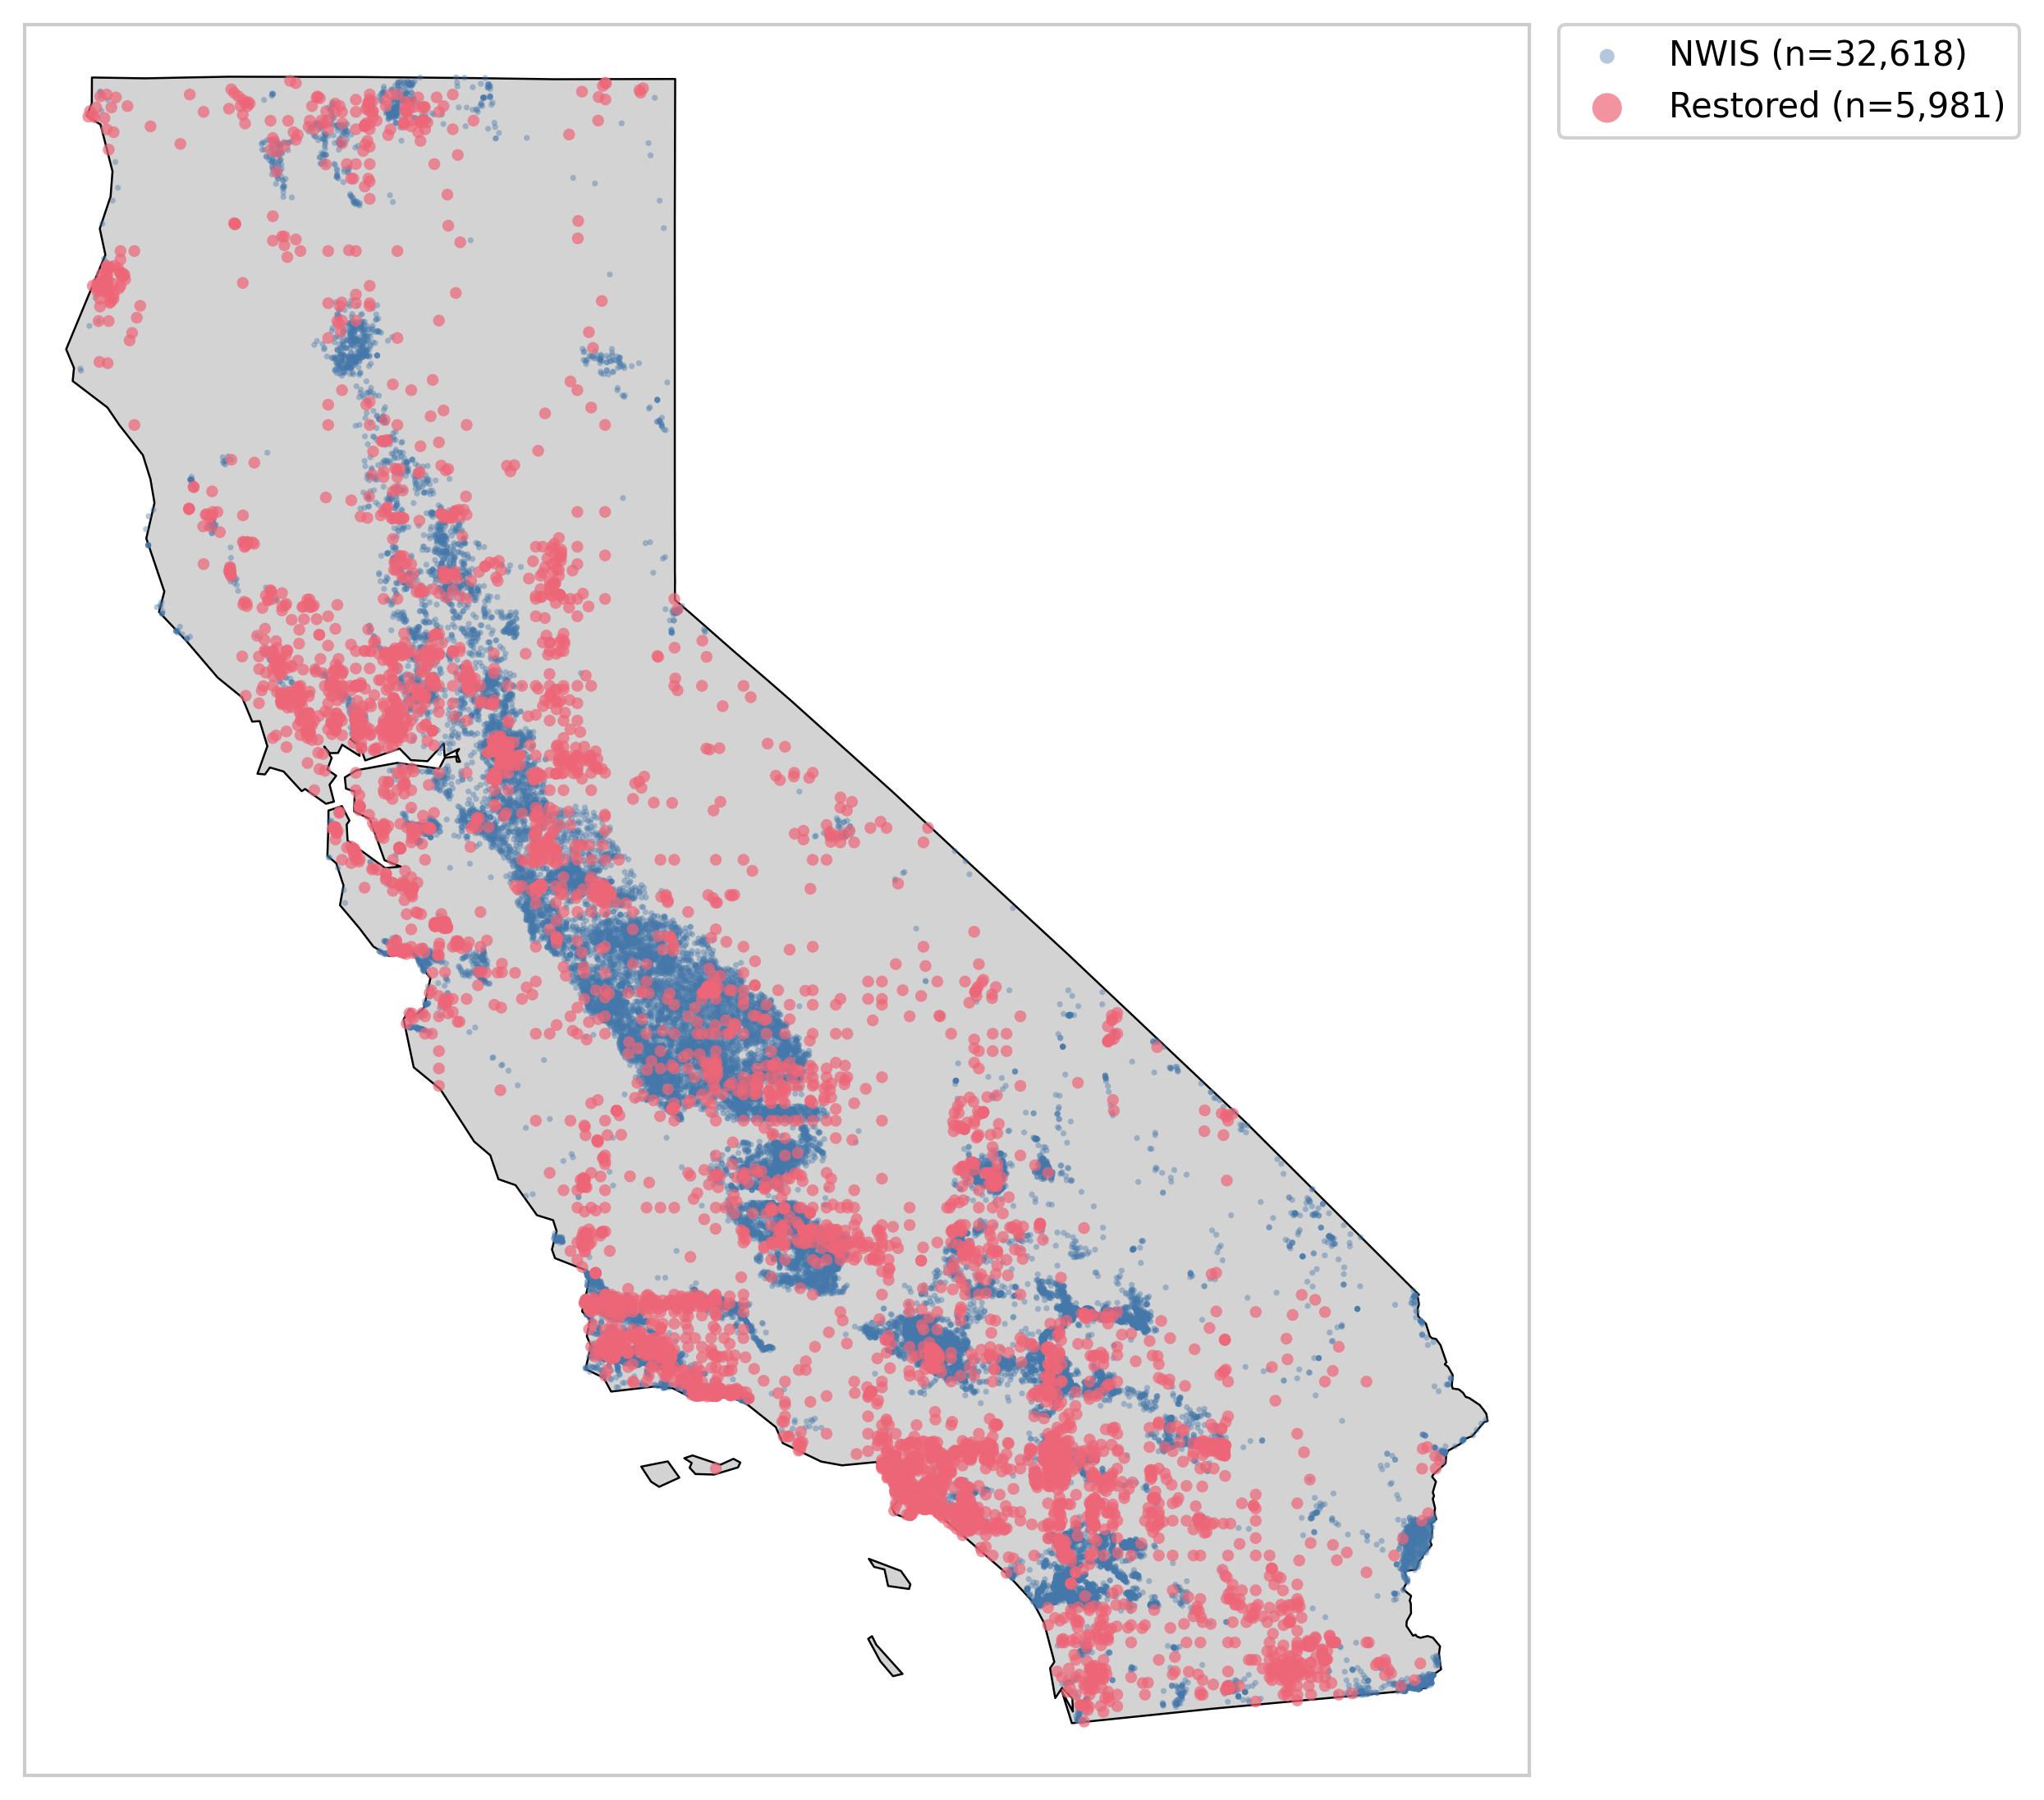

In [5]:
width  = CA_XMAX - CA_XMIN
height = CA_YMAX - CA_YMIN
fig, ax = plt.subplots(figsize=(8, 8 * height / width), dpi=300)

# CA state boundary
ca.plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0.6, zorder=1)

# NWIS sites first (behind restored — NWIS is more numerous here)
gdf_nwis.plot(ax=ax, color=NWIS_COLOR, markersize=3, alpha=0.4,
              edgecolor='none', zorder=2,
              label=f'NWIS (n={len(gdf_nwis):,})')

# Restored sites on top so they remain visible
gdf_restored.plot(ax=ax, color=RESTORED_COLOR, markersize=12, alpha=0.7,
                  edgecolor='none', zorder=3,
                  label=f'Restored (n={len(gdf_restored):,})')

ax.set_xlim(CA_XMIN, CA_XMAX)
ax.set_ylim(CA_YMIN, CA_YMAX)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_color('#cccccc')
    spine.set_linewidth(1.0)

ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0,
          markerscale=2.5, frameon=True, fancybox=True, framealpha=0.9)

plt.tight_layout()
out_path = figures_path / 'ca_groundwater_nwis_map.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()